# Dependencis

In [1]:
# UDA-enabled GPU cards (Ubuntu and Windows)
%pip install tensorflow
# CPU only
# %pip install tensorflow-cpu


  Using cached tensorflow-2.20.0-cp312-cp312-win_amd64.whl.metadata (4.6 kB)
Using cached tensorflow-2.20.0-cp312-cp312-win_amd64.whl (331.9 MB)


In [3]:
%pip show tensorflow

Name: tensorflow
Version: 2.19.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: d:\software\miniconda3\Lib\site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, ml-dtypes, numpy, opt-einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing-extensions, wrapt
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [1]:
import tensorflow as tf
import keras
print(tf.__version__)
print(tf.keras.__version__)
print(keras.__version__)

2.20.0
3.11.3
3.11.3


In [2]:
# common tools
import sys
from pathlib import Path
sys.path.append(Path.cwd().parent.as_posix())
# print(sys.path)

from ml_tools.common import inspect_submodules, inspect_functions

# Module

In [7]:
# inspect_submodules(tf)
# inspect_functions(tf)

# Basics
* https://www.tensorflow.org/guide/basics

## tensors

In [3]:
x = tf.constant([[1., 2., 3.],
                 [4., 5., 6.]])
print(x)
print(x.shape, x.dtype)

tf.Tensor(
[[1. 2. 3.]
 [4. 5. 6.]], shape=(2, 3), dtype=float32)
(2, 3) <dtype: 'float32'>


In [4]:
# mathematical operations on tensors
print(x + x)
print(5 * x)
print(x @tf.transpose(x))
print(tf.concat([x,x,x], axis=0))
print(tf.nn.softmax(x, axis=-1))
print(tf.reduce_sum(x))

tf.Tensor(
[[ 2.  4.  6.]
 [ 8. 10. 12.]], shape=(2, 3), dtype=float32)
tf.Tensor(
[[ 5. 10. 15.]
 [20. 25. 30.]], shape=(2, 3), dtype=float32)
tf.Tensor(
[[14. 32.]
 [32. 77.]], shape=(2, 2), dtype=float32)
tf.Tensor(
[[1. 2. 3.]
 [4. 5. 6.]
 [1. 2. 3.]
 [4. 5. 6.]
 [1. 2. 3.]
 [4. 5. 6.]], shape=(6, 3), dtype=float32)
tf.Tensor(
[[0.09003057 0.24472848 0.6652409 ]
 [0.09003057 0.24472848 0.6652409 ]], shape=(2, 3), dtype=float32)
tf.Tensor(21.0, shape=(), dtype=float32)


In [5]:
print(tf.convert_to_tensor([1, 2, 3]))
print(tf.reduce_sum([1, 2, 3]))

tf.Tensor([1 2 3], shape=(3,), dtype=int32)
tf.Tensor(6, shape=(), dtype=int32)


In [6]:
if tf.config.list_physical_devices('GPU'):
  print("TensorFlow **IS** using the GPU")
else:
  print("TensorFlow **IS NOT** using the GPU")

TensorFlow **IS NOT** using the GPU


In [7]:
# variables
var = tf.Variable([0.0, 0.0, 0.0])
print(var)

var.assign([1, 2, 3])
print(var)

var.assign_add([1, 1, 1])
print(var)

<tf.Variable 'Variable:0' shape=(3,) dtype=float32, numpy=array([0., 0., 0.], dtype=float32)>
<tf.Variable 'Variable:0' shape=(3,) dtype=float32, numpy=array([1., 2., 3.], dtype=float32)>
<tf.Variable 'Variable:0' shape=(3,) dtype=float32, numpy=array([2., 3., 4.], dtype=float32)>


## automatic differentiation

In [8]:
x = tf.Variable(1.0)
def f(x):
  y = x ** 2 + 2 * x - 5
  return y

print(f(x))

with tf.GradientTape() as tape:
  y = f(x)
g_x = tape.gradient(y, x)
print(g_x)

tf.Tensor(-2.0, shape=(), dtype=float32)
tf.Tensor(4.0, shape=(), dtype=float32)


## graphs, tf.function

In [9]:
@tf.function
def my_func(x):
  print('Tracing.\n')
  return tf.reduce_sum(x)

# need to construct graph
x = tf.constant([1, 2, 3])
print(my_func(x))
# reuse for same signature input
x = tf.constant([10, 9, 8])
print(my_func(x))
# new graph
x = tf.constant([10.0, 9.1, 8.2], dtype=tf.float32)
print(my_func(x))

Tracing.

tf.Tensor(6, shape=(), dtype=int32)
tf.Tensor(27, shape=(), dtype=int32)
Tracing.

tf.Tensor(27.3, shape=(), dtype=float32)


## module, layers, models

In [10]:
class MyModule(tf.Module):
  def __init__(self, value):
    self.weight = tf.Variable(value)

  @tf.function
  def multiply(self, x):
    return x * self.weight


mod = MyModule(3)
mod.multiply(tf.constant([1, 2, 3]))

# save the module
save_path = 'saved'
tf.saved_model.save(mod, save_path)
# load the module
reloaded = tf.saved_model.load(save_path)
reloaded.multiply(tf.constant([1, 2, 3]))

# cleanup
import shutil
shutil.rmtree(save_path)

INFO:tensorflow:Assets written to: saved\assets


INFO:tensorflow:Assets written to: saved\assets


## training loop

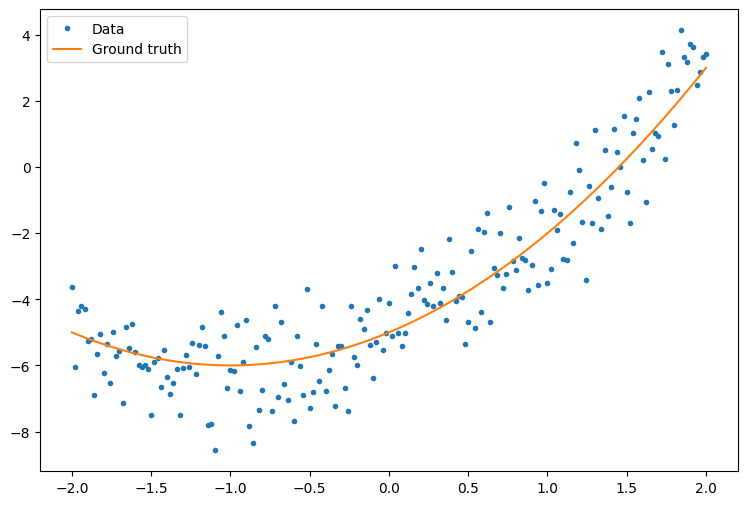

In [11]:
import matplotlib
from matplotlib import pyplot as plt

matplotlib.rcParams['figure.figsize'] = [9, 6]

# sample data
x = tf.linspace(-2, 2, 201)
x = tf.cast(x, tf.float32)


def f(x):
  y = x**2 + 2*x - 5
  return y


# add noise
y = f(x) + tf.random.normal(shape=[201])

plt.plot(x.numpy(), y.numpy(), '.', label='Data')
plt.plot(x, f(x), label='Ground truth')
plt.legend()
plt.show()

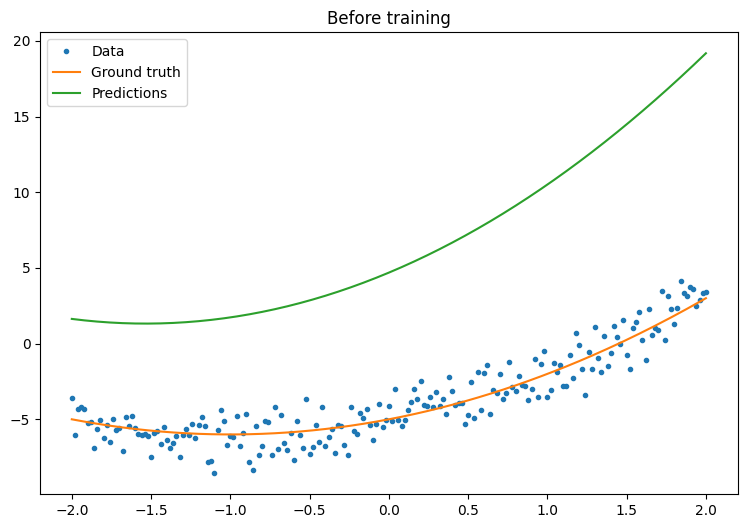

In [12]:
# model
class Model(tf.Module):
  def __init__(self):
    # random weight and bias
    rand_init = tf.random.uniform(shape=[3], minval=0., maxval=5., seed=22)
    self.w_q = tf.Variable(rand_init[0])
    self.w_l = tf.Variable(rand_init[1])
    self.b = tf.Variable(rand_init[2])

  @tf.function
  def __call__(self, x):
    return self.w_q * (x ** 2) + self.w_l * x + self.b


def plot_preds(x, y, f, model, title):
  plt.figure()
  plt.plot(x, y, '.', label='Data')
  plt.plot(x, f(x), label='Ground truth')
  plt.plot(x, model(x), label='Predictions')
  plt.title(title)
  plt.legend()
  plt.show()


quad_model = Model()
plot_preds(x, y, f, quad_model, 'Before training')

MSE for step 0: 55.645
MSE for step 10: 10.093
MSE for step 20: 4.184
MSE for step 30: 2.148
MSE for step 40: 1.437
MSE for step 50: 1.189
MSE for step 60: 1.102
MSE for step 70: 1.074
MSE for step 80: 1.065
MSE for step 90: 1.061


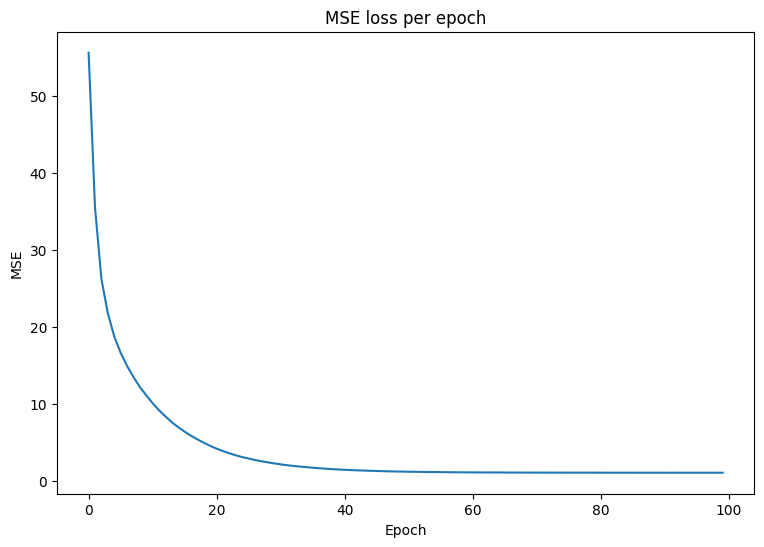

In [13]:
# loss of model
def mse_loss(y_pred, y):
  return tf.reduce_mean(tf.square(y_pred - y))


# dataset
batch_size = 32
dataset = tf.data.Dataset.from_tensor_slices((x, y))
dataset = dataset.shuffle(buffer_size=x.shape[0]).batch(batch_size)

# training parameters
epochs = 100
learning_rate = 0.01
losses = []

for epoch in range(epochs):
  for x_batch, y_batch in dataset:
    with tf.GradientTape() as tape:
      batch_loss = mse_loss(quad_model(x_batch), y_batch)
    # update parameters
    grads = tape.gradient(batch_loss, quad_model.variables)
    for g, v in zip(grads, quad_model.variables):
      v.assign_sub(learning_rate * g)
  # track model loss
  loss = mse_loss(quad_model(x), y)
  losses.append(loss)
  if epoch % 10 == 0:
    print(f'MSE for step {epoch}: {loss.numpy():0.3f}')

plt.plot(range(epochs), losses)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('MSE loss per epoch')
plt.show()

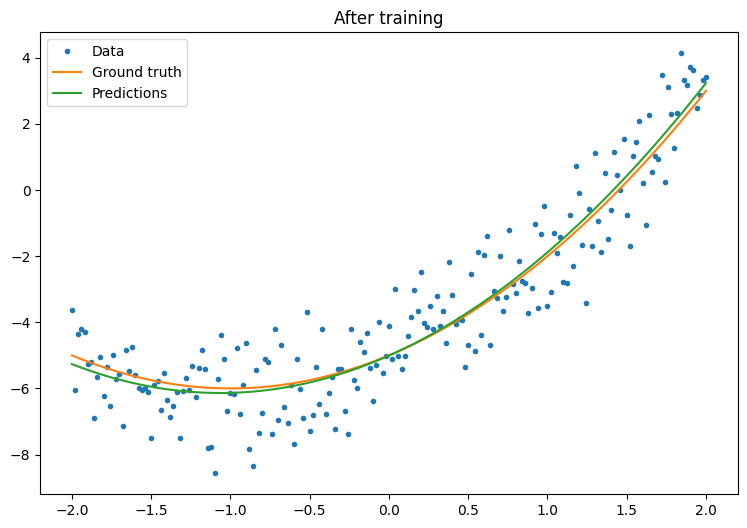

In [14]:
plot_preds(x, y, f, quad_model, 'After training')

## tf.keras

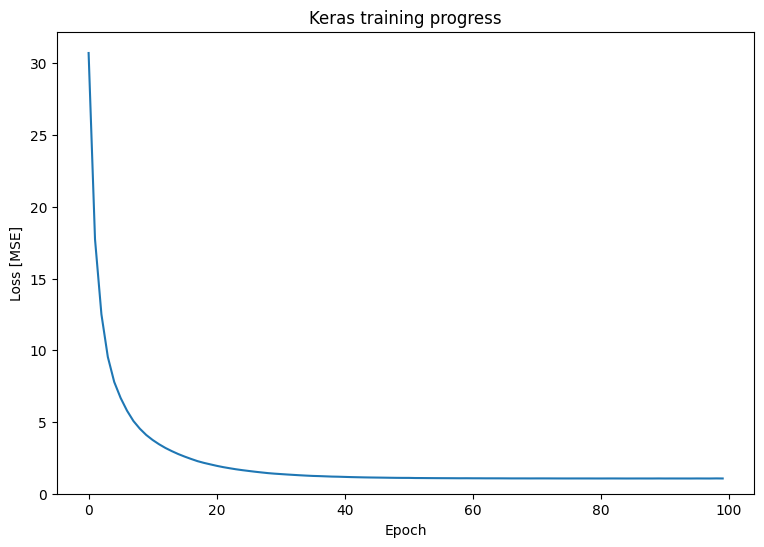

In [15]:
from tabnanny import verbose


new_model = tf.keras.Sequential([
    tf.keras.layers.Lambda(lambda x: tf.stack([x, x**2], axis=1)),
    tf.keras.layers.Dense(units=1, kernel_initializer=tf.random.normal)])

# compile
new_model.compile(
    loss=tf.keras.losses.MSE,
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01))

history = new_model.fit(x, y, epochs=100, batch_size=32, verbose=0)
model_path = 'my_new_model.keras'
new_model.save(model_path)

plt.plot(history.history['loss'])
plt.xlabel('Epoch')
plt.ylim([0, max(plt.ylim())])
plt.ylabel('Loss [MSE]')
plt.title('Keras training progress')
plt.show()

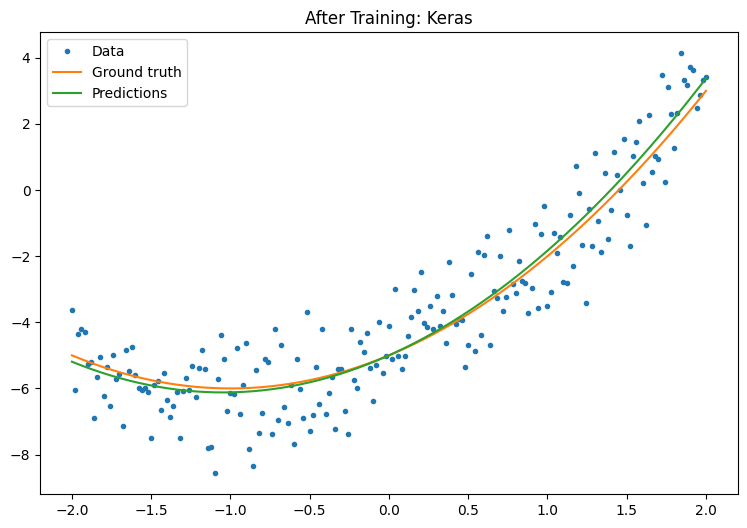

In [16]:
plot_preds(x, y, f, new_model, 'After Training: Keras')

In [17]:
# cleanup
import os
os.remove(model_path)

# TensorBoard

In [1]:
# Load the TensorBoard notebook extension.
%load_ext tensorboard

In [3]:
from datetime import datetime
import tensorboard

tensorboard.__version__

'2.20.0'

In [4]:
%env KERAS_HOME d:/workspace/github/hack-modeling/ml/codes/hands-on-ml/data/keras

env: KERAS_HOME=d:/workspace/github/hack-modeling/ml/codes/hands-on-ml/data/keras


In [8]:
# Keras HOME
import os
from pathlib import Path

os.environ['KERAS_HOME'] = Path.cwd().joinpath('data/keras').as_posix()
print(f"KERAS_HOME={os.environ['KERAS_HOME']}")

KERAS_HOME=d:/workspace/github/hack-modeling/ml/tools/tensorflow/data/keras


In [9]:
# Define the model.
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

(train_images, train_labels), _ = keras.datasets.fashion_mnist.load_data()
train_images = train_images / 255.0

# Define the Keras TensorBoard callback.
logdir="logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = keras.callbacks.TensorBoard(log_dir=logdir)

# Train the model.
model.fit(
    train_images,
    train_labels, 
    batch_size=64,
    epochs=5, 
    callbacks=[tensorboard_callback])

d:\software\miniconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 29s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 5s 1us/step
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7527 - loss: 0.7186
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8241 - loss: 0.4957
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8377 - loss: 0.4536
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8442 - loss: 0.4333
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8473 - loss: 0.4216


In [16]:
# %tensorboard --logdir logs

In [17]:
from tensorboard import notebook
notebook.list()

Known TensorBoard instances:
  - port 6006: logdir ./data/tf_logs (started 0:34:14 ago; pid 17200)
  - port 6006: logdir logs (started 0:22:27 ago; pid 18164)


In [15]:
# notebook.display(port=6006, height=1000)

# End